# RetainHub — Sistema de Alerta Temprana de Fuga de Clientes

**RetainHub** es un sistema de inteligencia artificial diseñado para ayudar a una tienda online a detectar, **antes de que sea demasiado tarde**, qué clientes están a punto de dejar de comprar.

La lógica es sencilla: si sabemos con antelación que un cliente está perdiendo interés, podemos reaccionar — ofrecerle un descuento, enviarle una oferta personalizada o simplemente contactarle — y evitar perderle.

---

## ¿Cómo está estructurado el proyecto?

El sistema se divide en tres grandes fases:

| Fase | Qué hacemos |
|---|---|
| **Fase 1 — ETL** | Cargamos los datos, los limpiamos y los dejamos listos para trabajar |
| **Fase 2 — Ingeniería de Características** | Creamos nuevas variables útiles y clasificamos a los clientes en segmentos |
| **Fase 3 — Modelo Predictivo** | Entrenamos un algoritmo que punta a cada cliente con su probabilidad de fuga |

---

## Fase 1 — Carga y Limpieza (ETL)

---

### 1.1. Selección y carga de datos

Para este sistema hemos utilizado el dataset **"Ecommerce Consumer Behavior Analysis Data"** disponible en Kaggle. Lo elegimos porque contiene exactamente lo que necesitamos para predecir si un cliente dejará de comprar: historial de transacciones, datos demográficos y patrones de comportamiento.

Las columnas principales son: ID de cliente, fecha de compra, importe gastado, categoría del producto, género y método de pago.

Dataset en [Kaggle](https://www.kaggle.com/datasets/salahuddinahmedshuvo/ecommerce-consumer-behavior-analysis-data?resource=download)

### Paso previo: instalación de dependencias

Antes de empezar, instalamos `kagglehub`, la librería oficial de Kaggle que permite descargar datasets directamente desde su plataforma con una sola línea de código. Si ya está instalada, esta celda no hace nada — es seguro ejecutarla siempre.

In [21]:
# %pip install kagglehub

### Importación de librerías y descarga del dataset

Aquí preparamos todas las herramientas que vamos a necesitar a lo largo del proyecto y descargamos el dataset de Kaggle. Piénsalo como preparar todos los ingredientes antes de ponerse a cocinar.

- **`pandas` / `numpy`:** Para manejar tablas de datos y hacer cálculos matemáticos.
- **`seaborn` / `matplotlib`:** Para crear gráficas y visualizaciones.
- **`sklearn`:** El kit de herramientas de Machine Learning — incluye el modelo, las métricas y la división de datos.
- **`SMOTE`:** Una técnica especial para corregir el desequilibrio entre clases (lo veremos en la Fase 3).

In [22]:
import pandas as pd
import os
import kagglehub
import shutil # Librería para mover archivos
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score
from imblearn.over_sampling import SMOTE # Herramienta para el desequilibrio

# Descarga del dataset (esto lo baja a una carpeta temporal de kagglehub)
path_download = kagglehub.dataset_download("salahuddinahmedshuvo/ecommerce-consumer-behavior-analysis-data")

# Define la carpeta de destino (raw)
carpeta_raw = '../data/raw'

# Crea la carpeta si no existe
if not os.path.exists(carpeta_raw):
    os.makedirs(carpeta_raw)

# Busca el archivo descargado y lo mueve a data/raw
for dirname, _, filenames in os.walk(path_download):
    for filename in filenames:
        ruta_origen = os.path.join(dirname, filename)
        ruta_dataset = os.path.join(carpeta_raw, filename)
        
        # Movemos el archivo de la caché de Kaggle a la carpeta del proyecto
        shutil.move(ruta_origen, ruta_dataset)
        print(f"Archivo movido a: {ruta_dataset}")

### 1.2. Limpieza inicial

---

Lo primero que hacemos al recibir cualquier dataset es comprobar que los datos están **completos y sin repeticiones**.

Imáginalo como revisar una agenda de contactos antes de usarla: queremos asegurarnos de que no hay entradas vacías ni el mismo contacto guardado dos veces.

In [23]:
# Guardo los datos en una variable e imprimo las columnas que tiene el dataset
datos = pd.read_csv(ruta_dataset)
print(datos.columns)
# Veo los valores nulos que hay y el porcentaje de ellos por columna
print("Valores nulos antes de borrar:")
print(datos.isnull().sum())
print (datos.isnull().mean() * 100)

# Comprobación de registros duplicados
duplicados = datos.duplicated().sum()
print(f"Registros duplicados encontrados: {duplicados}")

if duplicados > 0:
    datos = datos.drop_duplicates()
    print("Duplicados eliminados correctamente.")

# Verificación final de la forma del dataset tras la limpieza
print(f"Dimensiones finales del dataset: {datos.shape}")

Index(['Customer_ID', 'Age', 'Gender', 'Income_Level', 'Marital_Status',
       'Education_Level', 'Occupation', 'Location', 'Purchase_Category',
       'Purchase_Amount', 'Frequency_of_Purchase', 'Purchase_Channel',
       'Brand_Loyalty', 'Product_Rating',
       'Time_Spent_on_Product_Research(hours)', 'Social_Media_Influence',
       'Discount_Sensitivity', 'Return_Rate', 'Customer_Satisfaction',
       'Engagement_with_Ads', 'Device_Used_for_Shopping', 'Payment_Method',
       'Time_of_Purchase', 'Discount_Used', 'Customer_Loyalty_Program_Member',
       'Purchase_Intent', 'Shipping_Preference', 'Time_to_Decision'],
      dtype='object')
Valores nulos antes de borrar:
Customer_ID                                0
Age                                        0
Gender                                     0
Income_Level                               0
Marital_Status                             0
Education_Level                            0
Occupation                                 0
Loc

A continuación buscamos **valores atípicos** (outliers) en los importes de compra. Un valor atípico es un dato que se aleja muchísimo del resto — por ejemplo, una compra de 50.000 € cuando la media está en 200 €.

Para detectarlos usamos el **método IQR** (Rango Intercuartílico): calculamos dónde está el 25% y el 75% de los datos, medimos la distancia entre esos dos puntos, y cualquier valor que quede muy por fuera de ese rango se considera sospechoso.

Si dejáramos esos valores extremos sin tratar, podrían distorsionar todo el análisis y hacer que el modelo saque conclusiones equivocadas.

In [24]:
# Normalizamos nombres de columnas a minúsculas
datos.columns = [col.lower().replace(' ', '_').strip() for col in datos.columns]

# Limpieza agresiva de la columna purchase_amount
# Eliminamos símbolos de moneda, comas y espacios si existieran
if datos['purchase_amount'].dtype == 'object':
    datos['purchase_amount'] = datos['purchase_amount'].str.replace('$', '', regex=False).str.replace(',', '', regex=False).str.strip()

# Convertimos a numérico (los que no se puedan convertir serán NaN)
datos['purchase_amount'] = pd.to_numeric(datos['purchase_amount'], errors='coerce')

# Verificamos cuántos datos sobrevivieron antes de borrar nulos
nulos_generados = datos['purchase_amount'].isnull().sum()
print(f"Valores que no se pudieron convertir a número: {nulos_generados}")

# Borramos nulos
datos = datos.dropna(subset=['purchase_amount'])

# Cálculo de IQR
if not datos.empty:
    Q1 = datos['purchase_amount'].quantile(0.25)
    Q3 = datos['purchase_amount'].quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    print(f"Tipo de dato: {datos['purchase_amount'].dtype}")
    print(f"Filas útiles: {len(datos)}")
    print(f"Límites estadísticos: {limite_inferior:.2f} a {limite_superior:.2f}")
    
    # Identificar outliers
    outliers = datos[(datos['purchase_amount'] < limite_inferior) | (datos['purchase_amount'] > limite_superior)]
    print(f"Número de transacciones atípicas detectadas: {len(outliers)}")
else:
    print("¡ERROR CRÍTICO! El dataset se quedó vacío tras procesar Purchase_Amount.")

Valores que no se pudieron convertir a número: 0
Tipo de dato: float64
Filas útiles: 1000
Límites estadísticos: -177.89 a 729.10
Número de transacciones atípicas detectadas: 0


También comprobamos que los datos tengan **sentido lógico y físico**:

- Ningún importe de compra puede ser negativo (nadie paga cantidades negativas).
- La edad de los clientes debe estar entre 18 y 100 años (no tiene sentido tener un cliente de 5 años o de 200).

Si encontramos algún registro que no cumpla estas condiciones, lo eliminamos directamente.

In [25]:
# Validar que no existan montos de compra negativos (nombres en minúsculas)
conteo_negativos = (datos['purchase_amount'] <= 0).sum()
datos = datos[datos['purchase_amount'] > 0]

# Validar rango de edad (clientes entre 18 y 100 años)
conteo_edad_erronea = ((datos['age'] < 18) | (datos['age'] > 100)).sum()
datos = datos[(datos['age'] >= 18) & (datos['age'] <= 100)]

print(f"Registros eliminados por montos <= 0: {conteo_negativos}")
print(f"Registros eliminados por edades fuera de rango: {conteo_edad_erronea}")
print(f"Dimensiones actuales del dataset: {datos.shape}")

Registros eliminados por montos <= 0: 0
Registros eliminados por edades fuera de rango: 0
Dimensiones actuales del dataset: (1000, 28)


Por último, hacemos una limpieza del "ruido" en los textos:

1. **Eliminamos espacios extra** al principio y al final de cada campo — algo tan pequeño como un espacio de más puede hacer que `"Male"` y `"Male "` se traten como valores diferentes cuando en realidad son el mismo.
2. **Convertimos valores "vacíos disfrazados"** como `Unknown`, `n/a` o `?` a valores nulos reales (`NaN`), para que Python los reconozca como datos faltantes y los gestione correctamente.

In [26]:
# Eliminar espacios innecesarios en columnas de texto
columnas_obj = datos.select_dtypes(include=['object']).columns
for col in columnas_obj:
    datos[col] = datos[col].str.strip()

# Identificar y normalizar placeholders de 'nulos ocultos'
placeholders = ['?', 'n/a', 'Unknown', 'unknown', 'None']
datos.replace(placeholders, np.nan, inplace=True)

# Comprobar si han aparecido nuevos nulos reales tras la limpieza
print("Nuevos valores nulos detectados tras estandarización:")
print(datos.isnull().sum())

print("Nuevos valores nulos detectados tras estandarización:")
nulos = datos.isnull().sum()
print(nulos[nulos > 0]) # Solo mostramos las columnas que tienen nulos para hacer resumen

Nuevos valores nulos detectados tras estandarización:
customer_id                                0
age                                        0
gender                                     0
income_level                               0
marital_status                             0
education_level                            0
occupation                                 0
location                                   0
purchase_category                          0
purchase_amount                            0
frequency_of_purchase                      0
purchase_channel                           0
brand_loyalty                              0
product_rating                             0
time_spent_on_product_research(hours)      0
social_media_influence                   247
discount_sensitivity                       0
return_rate                                0
customer_satisfaction                      0
engagement_with_ads                      256
device_used_for_shopping                   0
p

### 1.3. Transformación de datos

---

Los datos ya están limpios, pero aún necesitamos **indicarle a Python qué tipo de dato es cada columna**. Esto es importante porque:

- Las columnas de texto con valores fijos (como género o canal de compra) deben marcarse como `category` para que Python las procese de forma más eficiente y con menos memoria.
- La columna de fecha de compra debe convertirse a formato fecha real, para poder hacer cálculos temporales como "¿cuántos días han pasado desde la última compra?".

In [27]:
# Convertir columnas categóricas para optimizar procesamiento
categoricas = ['gender', 'income_level', 'marital_status', 'education_level', 
               'occupation', 'location', 'purchase_category', 'purchase_channel', 
               'payment_method', 'discount_used', 'customer_loyalty_program_member', 'shipping_preference']

for col in categoricas:
    datos[col] = datos[col].astype('category')

# Aunque el dataset de Kaggle viene con Time_of_Purchase como string, 
# se convierte si el formato lo permite para futuros análisis de periodicidad.
datos['time_of_purchase'] = pd.to_datetime(datos['time_of_purchase'])

print("Tipos de datos actualizados:")
print(datos.dtypes)

Tipos de datos actualizados:
customer_id                                      object
age                                               int64
gender                                         category
income_level                                   category
marital_status                                 category
education_level                                category
occupation                                     category
location                                       category
purchase_category                              category
purchase_amount                                 float64
frequency_of_purchase                             int64
purchase_channel                               category
brand_loyalty                                     int64
product_rating                                    int64
time_spent_on_product_research(hours)           float64
social_media_influence                           object
discount_sensitivity                             object
return_rate        

Aprovechamos este momento para **estandarizar los nombres de todas las columnas**: los ponemos todos en minúsculas y sustituimos los espacios por guiones bajos (`_`).

¿Por qué importa esto? Porque así evitamos errores absurdos en el código, como que `datos['Purchase_Amount']` y `datos['purchase_amount']` sean tratados como dos columnas distintas cuando son exactamente la misma.

In [28]:
# Convertir todos los nombres de columnas a minúsculas y sustituir espacios por guiones bajos
datos.columns = [col.lower().replace(' ', '_') for col in datos.columns]

print("Nuevos nombres de columnas:")
print(datos.columns)

Nuevos nombres de columnas:
Index(['customer_id', 'age', 'gender', 'income_level', 'marital_status',
       'education_level', 'occupation', 'location', 'purchase_category',
       'purchase_amount', 'frequency_of_purchase', 'purchase_channel',
       'brand_loyalty', 'product_rating',
       'time_spent_on_product_research(hours)', 'social_media_influence',
       'discount_sensitivity', 'return_rate', 'customer_satisfaction',
       'engagement_with_ads', 'device_used_for_shopping', 'payment_method',
       'time_of_purchase', 'discount_used', 'customer_loyalty_program_member',
       'purchase_intent', 'shipping_preference', 'time_to_decision'],
      dtype='object')


Del mismo modo, unificamos el **formato de las etiquetas de texto** dentro de columnas como género o categoría de producto. Nos aseguramos de que todas sigan el mismo patrón: primera letra en mayúscula, el resto en minúsculas.

Sin esto, `"male"`, `"Male"` y `"MALE"` serían tres valores distintos para Python cuando en realidad representan exactamente lo mismo.

In [29]:
# Unificar formatos de texto en columnas categóricas
columnas_a_unificar = ['gender', 'location', 'purchase_category']

for col in columnas_a_unificar:
    if col in datos.columns:
        # Convertir a título (Primera letra mayúscula, resto minúscula)
        datos[col] = datos[col].astype(str).str.title()

print("Etiquetas de texto unificadas.")

Etiquetas de texto unificadas.


### 1.4. Resumen de la limpieza (ETL)

---

Una vez terminada la Fase 1, el estado del dataset es el siguiente:

- **Sin nulos** en las columnas críticas para el modelo.
- **Sin duplicados** — cada fila es un registro único.
- **Sin valores imposibles** — edades y montos dentro de rangos razonables.
- **Textos uniformes** — sin espacios extra ni formatos inconsistentes.
- **Tipos de datos correctos** — fechas como fechas, categorías como categorías.
- **Volumen intacto** — se mantienen los 1.000 registros originales.

El dataset está listo para pasar a la siguiente fase.

## Fase 2 — Ingeniería de Características

---

En esta fase convertimos los datos brutos en **señales útiles para el modelo**. Los datos tal como vienen del dataset no le dicen nada especialmente relevante a un algoritmo — necesitamos crear variables que capturen el comportamiento real de cada cliente.

La técnica que usamos se llama **análisis RFM**, uno de los métodos más clásicos del marketing para entender y segmentar clientes:

| Métrica | Pregunta que responde | Por qué importa |
|---|---|---|
| **R — Recencia** | ¿Cuántos días hace desde su última compra? | Un cliente que compró hace 300 días probablemente ya se fue |
| **F — Frecuencia** | ¿Cuántas veces ha comprado en total? | Quien compra a menudo suele ser más fiel |
| **M — Monetario** | ¿Cuánto dinero ha gastado en total? | Los clientes de alto valor merecen mayor atención |

---

### 2.1. Cálculo de las métricas RFM

Agrupamos todas las compras por cliente y calculamos sus tres métricas. Cada cliente queda resumido en tres números que representan su comportamiento de compra.

In [30]:
# Definimos la fecha de referencia (un día después de la última compra registrada)
fecha_referencia = datos['time_of_purchase'].max() + pd.Timedelta(days=1)

# Agrupamos por cliente para crear las métricas base
rfm = datos.groupby('customer_id').agg({
    'time_of_purchase': lambda x: (fecha_referencia - x.max()).days, # Recencia
    'purchase_amount': ['count', 'sum']                              # Frecuencia y Valor Monetario
})

# Renombrar columnas para claridad
rfm.columns = ['recencia', 'frecuencia', 'monetario']
rfm = rfm.reset_index()

print("Métricas RFM creadas con éxito.")
print(rfm.head())

Métricas RFM creadas con éxito.
   customer_id  recencia  frecuencia  monetario
0  00-107-4749       103           1     178.04
1  00-149-4481       331           1     464.76
2  00-264-3797       258           1     128.01
3  00-265-0556        60           1      68.02
4  00-275-9990       186           1     302.74


El bloque anterior es una primera versión del cálculo. El siguiente añade **validaciones adicionales** — como asegurarse de que no haya fechas vacías antes de calcular la recencia — para que el código sea más robusto frente a posibles errores en los datos.

In [31]:
# Aseguramos que no haya nulos en el ID de cliente ni en la fecha
datos_limpios = datos.dropna(subset=['customer_id', 'time_of_purchase']).copy()

# Forzamos la conversión a datetime y eliminamos fallos
datos_limpios['time_of_purchase'] = pd.to_datetime(datos_limpios['time_of_purchase'], errors='coerce')
datos_limpios = datos_limpios.dropna(subset=['time_of_purchase'])

# Fecha de referencia
fecha_ref = datos_limpios['time_of_purchase'].max() + pd.Timedelta(days=1)

# Agrupación
rfm = datos_limpios.groupby('customer_id').agg({
    'time_of_purchase': lambda x: (fecha_ref - x.max()).days,
    'purchase_amount': ['count', 'sum']
})

# Renombrar columnas de forma simple
rfm.columns = ['recencia', 'frecuencia', 'monetario']
rfm = rfm.reset_index()

print(f"Valores nulos en RFM: {rfm.isnull().sum().sum()}")
print(rfm.head())

Valores nulos en RFM: 0
   customer_id  recencia  frecuencia  monetario
0  00-107-4749       103           1     178.04
1  00-149-4481       331           1     464.76
2  00-264-3797       258           1     128.01
3  00-265-0556        60           1      68.02
4  00-275-9990       186           1     302.74


### 2.2. Segmentación de clientes

---

Con las tres métricas calculadas, ahora **puntuamos a cada cliente** en cada dimensión con una nota del **1 al 5** (5 = excelente, 1 = preocupante).

- **Recencia:** 5 = compró hace muy poco, 1 = lleva mucho tiempo sin comprar.
- **Frecuencia:** 5 = compra muy a menudo, 1 = ha comprado muy pocas veces.
- **Monetario:** 5 = gasta mucho, 1 = gasta poco.

Con esas tres notas combinadas, clasificamos a cada cliente en uno de estos cuatro segmentos:

| Segmento | Quiénes son |
|---|---|
| **Campeones** | Compraron recientemente, compran a menudo y gastan mucho — los mejores clientes |
| **Leales / Potenciales** | Buenos clientes que todavía tienen margen de crecer |
| **En Riesgo / Perdidos** | Llevan mucho tiempo sin comprar — son nuestro objetivo principal |
| **Otros** | Clientes intermedios sin un patrón claro |

In [32]:
# Calcular el ranking porcentual (de 0 a 1) para cada métrica
# rank(pct=True) calcula en qué percentil está cada cliente
r_pct = rfm['recencia'].rank(pct=True, method='first')
f_pct = rfm['frecuencia'].rank(pct=True, method='first')
m_pct = rfm['monetario'].rank(pct=True, method='first')

# Convertir percentiles a notas del 1 al 5
# Recencia: Menor valor es mejor, por eso restamos del 6
rfm['R'] = (r_pct.apply(lambda x: 1 if x <= 0.2 else 2 if x <= 0.4 else 3 if x <= 0.6 else 4 if x <= 0.8 else 5))
rfm['R'] = 6 - rfm['R'] # Invertimos: 1 es lejos, 5 es reciente

rfm['F'] = (f_pct.apply(lambda x: 1 if x <= 0.2 else 2 if x <= 0.4 else 3 if x <= 0.6 else 4 if x <= 0.8 else 5))
rfm['M'] = (m_pct.apply(lambda x: 1 if x <= 0.2 else 2 if x <= 0.4 else 3 if x <= 0.6 else 4 if x <= 0.8 else 5))

# Score combinado
rfm['rfm_score'] = rfm['R'].astype(str) + rfm['F'].astype(str) + rfm['M'].astype(str)

# Etiquetado lógico
def segmentar(s):
    if s[0] >= '4' and s[1] >= '4': return 'Campeones'
    if s[0] >= '3' and s[2] >= '3': return 'Leales / Potenciales'
    if s[0] <= '2': return 'En Riesgo / Perdidos'
    return 'Otros'

rfm['segmento_cliente'] = rfm['rfm_score'].apply(segmentar)

print("Segmentación terminada con éxito.")
print(rfm['segmento_cliente'].value_counts())

Segmentación terminada con éxito.
segmento_cliente
En Riesgo / Perdidos    400
Leales / Potenciales    260
Otros                   183
Campeones               157
Name: count, dtype: int64


### 2.3. Visualización de la segmentación

---

Antes de seguir, hacemos una pausa para **ver visualmente si la segmentación tiene sentido**.

Si el gráfico mostrara que casi todos los clientes están en el mismo segmento, sabríamos que algo ha salido mal. Lo que queremos ver es una distribución variada: suficientes clientes en cada categoría para que el modelo tenga ejemplos de todos los tipos y pueda aprender a distinguirlos.

C:\Users\Usuario\AppData\Local\Temp\ipykernel_25308\2881047855.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=rfm, x='segmento_cliente', palette='viridis', order=rfm['segmento_cliente'].value_counts().index)


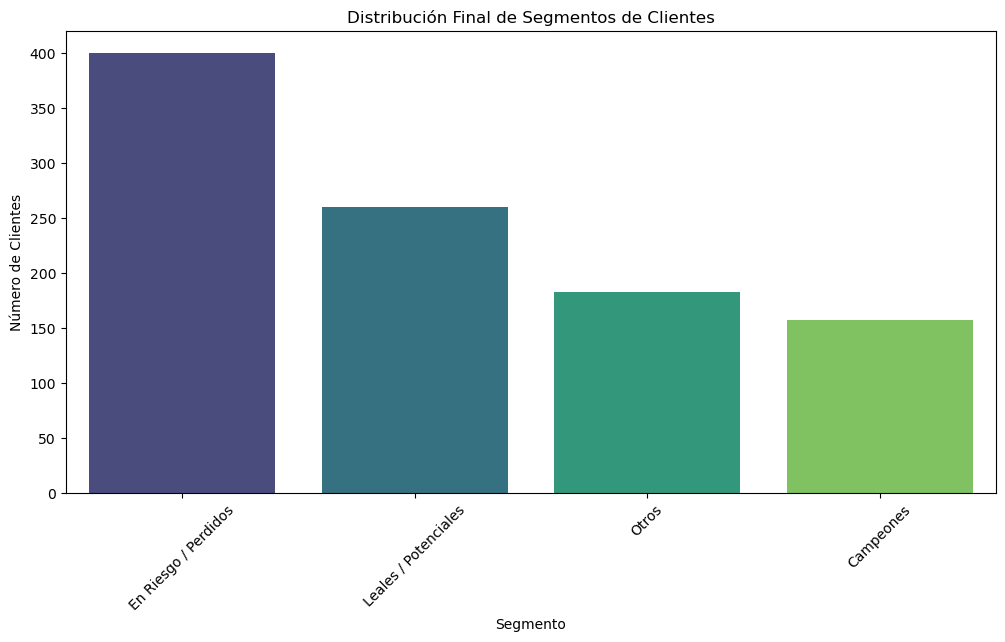

In [33]:
plt.figure(figsize=(12, 6))
sns.countplot(data=rfm, x='segmento_cliente', palette='viridis', order=rfm['segmento_cliente'].value_counts().index)
plt.title('Distribución Final de Segmentos de Clientes')
plt.xlabel('Segmento')
plt.ylabel('Número de Clientes')
plt.xticks(rotation=45)
plt.show()

### 2.4. Preparación del dataset para el modelo

---

Los algoritmos de Machine Learning **solo entienden números**. Pero muchas de nuestras columnas son texto (como `"Male"`, `"Electronics"` o `"PayPal"`). Necesitamos convertirlas.

Para eso usamos **One-Hot Encoding**: cada valor posible de una columna de texto se convierte en una columna nueva de ceros y unos. Por ejemplo, la columna `género` con valores `Male` y `Female` se convierte en:
- `gender_Male` → 1 si es hombre, 0 si no
- `gender_Female` → 1 si es mujer, 0 si no

También **normalizamos** las columnas numéricas como edad e importe de compra, para que el modelo no interprete que la edad es más importante que el importe solo porque sus números son mayores.

In [34]:
# LIMPIEZA DE LLAVES Y UNIÓN
# Aseguramos que los IDs no tengan espacios y sean del mismo tipo (string)
datos['customer_id'] = datos['customer_id'].astype(str).str.strip()
rfm['customer_id'] = rfm['customer_id'].astype(str).str.strip()

# Realizamos la unión
datos_final = datos.merge(rfm[['customer_id', 'segmento_cliente', 'rfm_score']], on='customer_id', how='left')

# Verificación de seguridad
if datos_final.shape[0] == 0:
    print("¡ERROR: El merge resultó en 0 filas! Revisa si 'customer_id' existe en ambos dataframes.")
else:
    # CODIFICACIÓN (One-Hot Encoding)
    # Seleccionamos solo las columnas que realmente existen en el dataframe
    columnas_disponibles = datos_final.columns.tolist()
    columnas_cat = [c for c in ['gender', 'income_level', 'purchase_category', 
                                'purchase_channel', 'payment_method', 'segmento_cliente'] 
                    if c in columnas_disponibles]

    datos_preparados = pd.get_dummies(datos_final, columns=columnas_cat, drop_first=True)

    # TRATAMIENTO DE NULOS ANTES DE ESCALAR
    # El Scaler falla si hay nulos. Llenamos nulos en edad con la mediana y en monto con 0.
    datos_preparados['age'] = datos_preparados['age'].fillna(datos_preparados['age'].median())
    datos_preparados['purchase_amount'] = datos_preparados['purchase_amount'].fillna(0)

    # NORMALIZACIÓN (Escalado)
    from sklearn.preprocessing import StandardScaler
    
    scaler = StandardScaler()
    cols_a_escalar = ['age', 'purchase_amount']
    
    # Solo escalamos si el dataframe tiene datos
    if not datos_preparados.empty:
        datos_preparados[cols_a_escalar] = scaler.fit_transform(datos_preparados[cols_a_escalar])
        
        # LIMPIEZA FINAL DE COLUMNAS
        columnas_sobrantes = ['customer_id', 'time_of_purchase', 'location', 'rfm_score']
        datos_preparados = datos_preparados.drop(columns=[c for c in columnas_sobrantes if c in datos_preparados.columns])

        print("----- PROCESO FINALIZADO -----")
        print(f"Dataset listo. Filas: {datos_preparados.shape[0]}, Columnas: {datos_preparados.shape[1]}")
    else:
        print("Error: El dataset preparado quedó vacío.")

----- PROCESO FINALIZADO -----
Dataset listo. Filas: 1000, Columnas: 60


### 2.5. Guardado del dataset procesado

---

Guardamos el dataset ya transformado en un archivo CSV. Esto tiene dos ventajas importantes:

1. **Punto de guardado:** Si algo falla en la Fase 3, no tenemos que volver a ejecutar todo desde el principio — simplemente cargamos este archivo.
2. **Portabilidad:** Cualquier miembro del equipo puede usar este dataset limpio sin necesidad de ejecutar las fases anteriores.

In [35]:
# Crea la carpeta si no existe
carpeta_processed = '../data/processed'
if not os.path.exists(carpeta_processed):
    os.makedirs(carpeta_processed)

# Guardamos el dataset listo para Machine Learning
datos_preparados.to_csv('../data/processed/processed_data.csv', index=False)
print("Archivo 'processed_data.csv' guardado con éxito.")

Archivo 'processed_data.csv' guardado con éxito.


## Fase 3 — Modelado Predictivo y Detección de Abandono

---

Esta es la fase clave: aquí es donde el sistema **aprende a predecir qué clientes van a abandonar**.

El algoritmo que usamos se llama **Random Forest** (Bosque Aleatorio). La idea es fácil de entender: en lugar de consultar a un solo experto para tomar una decisión, consultas a 100 expertos distintos y te quedas con la respuesta de la mayoría. Eso es exactamente lo que hace este algoritmo — construye 100 árboles de decisión independientes y combina sus predicciones.

---

### 3.2. Carga de datos y creación del target

Cargamos el CSV procesado en la Fase 2 y creamos la variable que queremos predecir: el **churn** (abandono).

- `churn = 1` → El cliente está en riesgo de irse (queremos que el modelo lo detecte)
- `churn = 0` → El cliente no está en riesgo

Luego dividimos los datos en dos grupos:
- **Entrenamiento (80%):** Los datos con los que el modelo aprende.
- **Test (20%):** Los datos que guardamos para comprobar si lo aprendido funciona con casos nuevos que el modelo nunca ha visto.

In [36]:
# Carga y Limpieza de columnas no numéricas
df = pd.read_csv('../data/processed/processed_data.csv') 

# Creamos el target 'y'
target_df = rfm[['customer_id', 'segmento_cliente']].copy()
target_df['churn'] = target_df['segmento_cliente'].apply(lambda x: 1 if x == 'En Riesgo / Perdidos' else 0)

# Solo nos quedamos con las columnas que son números (float, int) o booleanos
X = df.select_dtypes(include=[np.number, 'bool']).copy()

print(f"Columnas numéricas detectadas para el modelo: {X.columns.tolist()}")

y = target_df['churn']

# Alineación por si acaso los tamaños difieren
X = X.iloc[:len(y)]
y = y.iloc[:len(X)]

# División
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

Columnas numéricas detectadas para el modelo: ['age', 'purchase_amount', 'frequency_of_purchase', 'brand_loyalty', 'product_rating', 'time_spent_on_product_research(hours)', 'return_rate', 'customer_satisfaction', 'discount_used', 'customer_loyalty_program_member', 'time_to_decision', 'gender_Bigender', 'gender_Female', 'gender_Genderfluid', 'gender_Genderqueer', 'gender_Male', 'gender_Non-Binary', 'gender_Polygender', 'income_level_Middle', 'purchase_category_Arts & Crafts', 'purchase_category_Baby Products', 'purchase_category_Beauty & Personal Care', 'purchase_category_Books', 'purchase_category_Clothing', 'purchase_category_Electronics', 'purchase_category_Food & Beverages', 'purchase_category_Furniture', 'purchase_category_Gardening & Outdoors', 'purchase_category_Groceries', 'purchase_category_Health Care', 'purchase_category_Health Supplements', 'purchase_category_Home Appliances', 'purchase_category_Hotels', 'purchase_category_Jewelry & Accessories', 'purchase_category_Luxury G

### 3.3. Corrección del desequilibrio con SMOTE

---

Tenemos un problema clásico en los proyectos de predicción de abandono: **hay muchos más clientes que NO se van que clientes que SÍ se van**. Si entrenamos el modelo tal cual, aprenderá a decir siempre "este cliente no se va" y parecerá muy preciso en papel — pero nunca detectaría a nadie en riesgo real.

Para solucionarlo usamos **SMOTE** (Synthetic Minority Oversampling Technique): una técnica que genera ejemplos artificiales pero realistas de clientes en riesgo, hasta que los dos grupos quedan equilibrados al 50%.

Es como entrenar a un portero de fútbol usando solo vídeos de paradas fáciles — nunca aprendería a parar los penaltis difíciles. SMOTE se encarga de que haya suficientes ejemplos complicados para entrenar bien.

In [37]:
# Aplicar SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"Nueva distribución equilibrada: \n{y_train_res.value_counts()}")

Nueva distribución equilibrada: 
churn
0    480
1    480
Name: count, dtype: int64


### 3.4. Entrenamiento del modelo Random Forest

---

Con los datos ya equilibrados, entrenamos nuestro **Random Forest**. Los parámetros clave que hemos configurado son:

- **`n_estimators=100`:** El bosque está formado por 100 árboles de decisión que votan en conjunto.
- **`max_depth=10`:** Cada árbol puede hacer como máximo 10 niveles de preguntas antes de dar una respuesta. Esto evita que el modelo se "aprenda de memoria" los datos de entrenamiento y luego falle con datos nuevos — un problema conocido como *overfitting* (sobreajuste).

In [38]:
# Creamos el modelo
model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)

# Entrenamos con los datos equilibrados por SMOTE
model.fit(X_train_res, y_train_res)

print("Modelo entrenado exitosamente con datos balanceados.")

Modelo entrenado exitosamente con datos balanceados.


### 3.5. Generación del score de riesgo (0–100%)

---

El modelo ya está entrenado. Ahora lo usamos para **puntuar a cada cliente** del conjunto de test con una probabilidad de abandono entre el 0% y el 100%.

Por ejemplo:
- Un cliente con **65%** → Alta probabilidad de que se vaya. Hay que actuar con urgencia.
- Un cliente con **10%** → Baja probabilidad. Está satisfecho, no necesita intervención.

Como resultado final, generamos un listado con los **100 clientes con mayor riesgo de fuga** — este es el entregable práctico del sistema: la lista de prioridades que el equipo de retención necesita para actuar.

In [39]:
# Calculamos la probabilidad de abandono (clase 1)
probabilidades = model.predict_proba(X_test)[:, 1] # predict_proba nos da dos columnas: [prob_quedarse, prob_irse]. Tomamos la segunda [:, 1]

# Recuperamos los IDs de cliente originales
ids_clientes = rfm.loc[X_test.index, 'customer_id'].values # Usamos el índice de X_test para buscar el customer_id en la tabla rfm original

# Creamos un DataFrame con los resultados detallados
resultados = pd.DataFrame({
    'id_cliente': ids_clientes,
    'probabilidad_churn_%': (probabilidades * 100).round(2)
})

# Generamos el top 100 clientes con mayor riesgo de fuga
top_100_riesgo = resultados.sort_values(by='probabilidad_churn_%', ascending=False).head(100)


# Crea la carpeta si no existe
carpeta_results = '../results'
if not os.path.exists(carpeta_results):
    os.makedirs(carpeta_results)
# Guardamos el archivo
top_100_riesgo.to_csv('../results/top_100_riesgo_clientes.csv', index=False)

print("----- REPORTE DE RIESGO GENERADO -----")
print(f"Se han identificado {len(top_100_riesgo)} clientes prioritarios.")
print("\nPrimeros 10 clientes en riesgo máximo:")
print(top_100_riesgo.head(10))

----- REPORTE DE RIESGO GENERADO -----
Se han identificado 100 clientes prioritarios.

Primeros 10 clientes en riesgo máximo:
      id_cliente  probabilidad_churn_%
185  93-093-0556                 63.80
180  35-418-0288                 62.82
176  63-631-8261                 62.51
115  79-939-5393                 62.03
183  75-915-9803                 61.32
5    15-711-4107                 60.30
47   78-905-2660                 60.27
168  10-330-6387                 60.23
45   36-214-1586                 59.64
86   34-788-8387                 59.35
